# DÍA 1: Tu Primera Red Neuronal
## Deep Learning Bootcamp

En este notebook vas a entrenar tu primer modelo de deep learning desde cero.

**Objetivos**:
1. Cargar datos (MNIST)
2. Construir una red neuronal
3. Entrenarla
4. Evaluarla
5. Experimentar con arquitecturas


## PASO 1: Importar librerías

In [37]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import metrics

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponible: {len(tf.config.list_physical_devices('GPU'))}")

TensorFlow version: 2.19.0
GPU disponible: 0


## PASO 2: Cargar datos (MNIST)

MNIST = 70,000 imágenes de dígitos (0-9) en blanco y negro (28x28 píxeles)

Vamos a empezar clasificando solo 0 vs 1 (binario) para simplificar.

Datos descargados:
X_train shape:  (60000, 28, 28)
y_train shape:  (60000,)


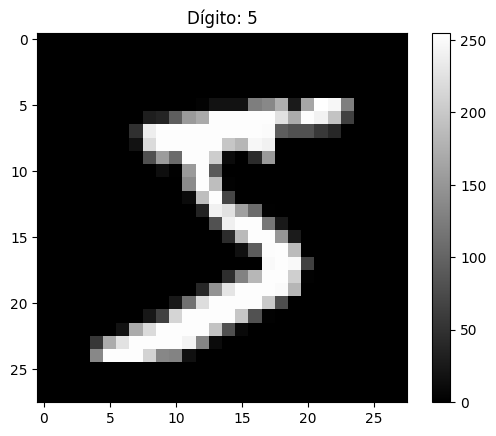

In [5]:
# Descargar MNIST
(X_train_full, y_train_full), (X_test_full, y_test_full) = keras.datasets.mnist.load_data()

print("Datos descargados:")
print("X_train shape: ", X_train_full.shape)
print("y_train shape: ", y_train_full.shape)

# Ver una imagen
plt.imshow(X_train_full[0], cmap='gray')
plt.title(f'Dígito: {y_train_full[0]}')
plt.colorbar()
plt.show()

In [6]:
X_train_full[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [7]:
# Normalizar (convertir a 0-1)
X_train = X_train_full.astype('float32') / 255.0
X_test = X_test_full.astype('float32') / 255.0

print(f"Valor minimo y maximo de la imagen: [{X_train.min()}, {X_train.max()}]")

Valor minimo y maximo de la imagen: [0.0, 1.0]


## PASO 3: Filtrar solo 0 y 1 (clasificación binaria)

Crear máscaras para 0 y 1, y filtramos los datos en cada uno de los conjuntos de datos. 

In [10]:
mask_train = (y_train_full == 0) | (y_train_full == 1)
mask_test = (y_test_full == 0) | (y_test_full == 1)

X_train_bin = X_train[mask_train]
y_train_bin = y_train_full[mask_train]
X_test_bin = X_test[mask_test]
y_test_bin = y_test_full[mask_test]

print("Datos filtrados:")
print(X_train_bin.shape)
print(y_train_bin.shape)
print(f"Distribución: {np.bincount(y_train_bin)}")

Datos filtrados:
(12665, 28, 28)
(12665,)
Distribución: [5923 6742]


## PASO 3: Aplanamos las imagenes.

In [18]:
X_train_bin[0].shape

(28, 28)

In [13]:
X_train_flat = X_train_bin.reshape(-1, 28*28)
X_test_flat = X_test_bin.reshape(-1, 28*28)

print("Datos aplanados:")
print("X_train_flat shape: ", X_train_flat.shape)

Datos aplanados:
X_train_flat shape:  (12665, 784)


In [14]:
X_train_flat[0].shape

(784,)

## PASO 5: Construir la red neuronal

Arquitectura:
- Input: 784 (28x28 píxeles)
- Capa oculta 1: 64 neuronas
- Capa oculta 2: 32 neuronas  
- Output: 1 neurona (probabilidad 0-1, es 1 o es 0)

In [24]:
model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(784,)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model.summary()

c:\Users\Diego Nuñez\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,353 (204.50 KB)

 Trainable params: 52,353 (204.50 KB)

 Non-trainable params: 0 (0.00 B)

## PASO 5: Compilar el modelo

- **Optimizer**: Adam (mejora los pesos)
- **Loss**: Binary Crossentropy (mide error para clasificación binaria)
- **Metrics**: Accuracy (porcentaje de aciertos)

In [28]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

## PASO 6: ENTRENAR

- **epochs=10**: Pasa por los datos 10 veces
- **batch_size=32**: Procesa 32 imágenes a la vez
- **validation_split=0.2**: Usa 20% de datos para validación (no entrenamiento)

**Observación**:
- Loss baja → Modelo aprende
- Accuracy sube → Mejora la predicción

In [29]:
history = model.fit(X_train_flat, y_train_bin,
                    epochs=10,
                    batch_size=32,
                    validation_split=0.2,
                    verbose=1)

Epoch 1/10
317/317 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9997 - loss: 0.0024 - val_accuracy: 0.9996 - val_loss: 4.7306e-04
Epoch 2/10
317/317 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 1.1994e-04 - val_accuracy: 1.0000 - val_loss: 3.1880e-04
Epoch 3/10
317/317 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 1.0000 - loss: 6.3600e-06 - val_accuracy: 0.9996 - val_loss: 3.5802e-04
Epoch 4/10
317/317 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 1.0000 - loss: 1.3722e-05 - val_accuracy: 1.0000 - val_loss: 1.2765e-04
Epoch 5/10
317/317 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 1.0000 - loss: 2.8433e-06 - val_accuracy: 1.0000 - val_loss: 1.3042e-04
Epoch 6/10
317/317 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 1.0000 - loss: 3.7878e-06 - val_accuracy: 1.0000 - val_loss: 1.3061e-04
Epoch 7/10
317/317 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 1.0000 - loss: 1.6308e-06 - val_accuracy: 1.0000 - val_loss: 1.2740e-04
Epoch 8/10
317/317 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step 

## PASO 7: Evaluar en test

Mira cómo se desempeña en datos que NUNCA ha visto

In [31]:
loss, accuracy = model.evaluate(X_test_flat, y_test_bin)

print("=== RESULTADOS EN TEST ===")
print(f"Loss: {loss:.4f}")
print(f"Accuracy: {accuracy:.2%}")
print("Interpretación:")
print(f"La red puede clasificar 0 vs 1 con {accuracy:.0%} de exactitud")
print(f"De 100 imágenes, acertaría {int(accuracy*100)}")

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 2.6287e-04
=== RESULTADOS EN TEST ===
Loss: 0.0033
Accuracy: 99.95%
Interpretación:
La red puede clasificar 0 vs 1 con 100% de exactitud
De 100 imágenes, acertaría 99


## PASO 8: Visualizar el entrenamiento

Gráficos de Loss y Accuracy durante los 10 epochs

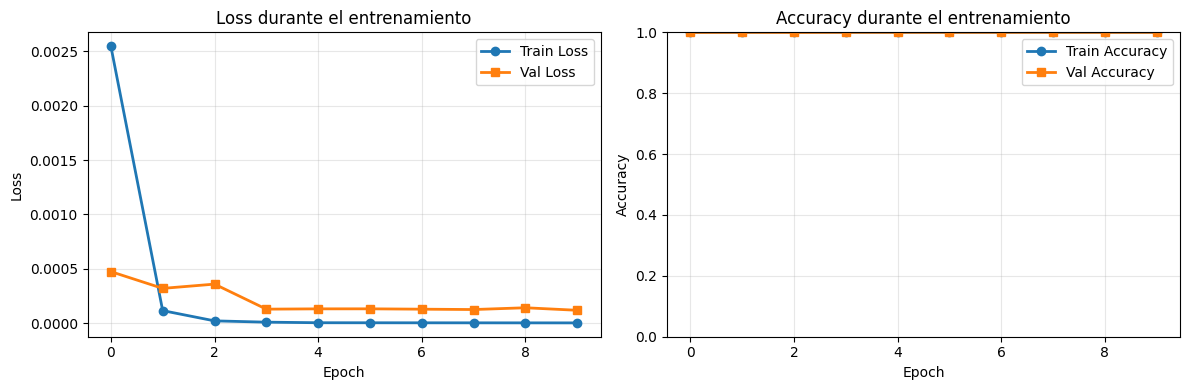

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2, marker='o')
axes[0].plot(history.history['val_loss'], label='Val Loss', linewidth=2, marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss durante el entrenamiento')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2, marker='o')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2, marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy durante el entrenamiento')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

## PASO 9: Hacer predicciones

Predice en nuevas imágenes

In [34]:
predictions = model.predict(X_test_flat[:5])

predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step


array([[9.9999994e-01],
       [2.3987941e-14],
       [1.0000000e+00],
       [1.1640681e-14],
       [2.2458607e-13]], dtype=float32)

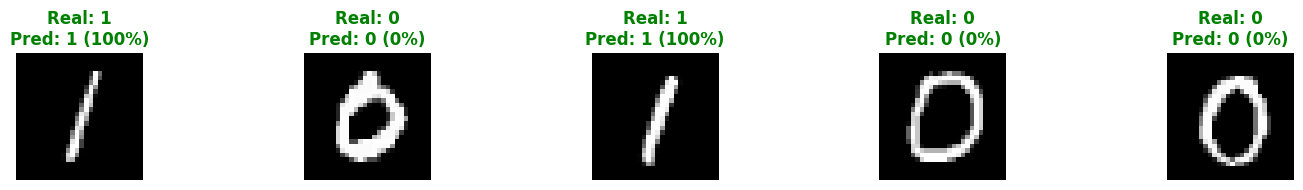

In [35]:
fig, axes = plt.subplots(1, 5, figsize=(15, 2))

for i in range(5):
    axes[i].imshow(X_test_bin[i], cmap='gray')
    
    pred_prob = predictions[i][0]
    pred_class = 1 if pred_prob > 0.5 else 0
    real_class = y_test_bin[i]
    
    color = 'green' if pred_class == real_class else 'red'
    
    title = f"Real: {real_class}\nPred: {pred_class} ({pred_prob:.0%})"
    axes[i].set_title(title, color=color, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.show()
